<a href="https://colab.research.google.com/github/truongphuclam2007/PROJECT/blob/main/ANALYSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [69]:
customers = pd.read_csv('/content/olist_customers_dataset.csv')
orders = pd.read_csv('/content/olist_orders_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
items = pd.read_csv('/content/olist_order_items_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
translation = pd.read_csv('/content/product_category_name_translation.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')

##DATA DICTIONARY
Dưới đây là danh sách các biến đặc trưng (features) được giữ lại để đưa vào mô hình dự báo Churn, kèm theo ý nghĩa chi tiết:

**Biến mục tiêu (Target Variable):**
* `is_churn`: Trạng thái rời bỏ của khách hàng. Mang giá trị `1` (Churn - Rời bỏ) nếu khách hàng không có giao dịch nào trong hơn 180 ngày qua, và `0` (Stay - Ở lại) nếu ngược lại.

**Biến dự báo (Predictor Variables):**
* `freight_ratio`: Tỷ lệ phí vận chuyển (Phí vận chuyển / Giá trị đơn hàng). Chỉ số này giúp đánh giá xem độ đắt đỏ của phí ship có ảnh hưởng đến quyết định quay lại của khách hàng hay không.
* `customer_state`: Bang/Khu vực địa lý sinh sống của khách hàng (Ví dụ: SP, RJ...). Biến này đã được mã hóa thành số (Label Encoding).
* `delivery_delay`: Độ trễ giao hàng tính bằng ngày (Ngày giao thực tế - Ngày giao dự kiến). Nếu giá trị âm (-), nghĩa là đơn hàng được giao sớm hơn dự kiến.
* `product_category_name_english`: Danh mục sản phẩm khách hàng đã mua. Dữ liệu đã được giảm nhiễu bằng cách chỉ giữ lại Top 10 danh mục phổ biến nhất, phần còn lại được gom chung thành nhóm `Others`.
* `quantity`: Số lượng sản phẩm trong đơn hàng.
* `price`: Giá trị thực tế của sản phẩm.

In [70]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [71]:
#DELIVERY DELAY
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

#(Actual - Estimated)
orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['is_late'] = orders['delivery_delay'].apply(lambda x: 1 if x > 0 else 0)

In [72]:
#FILTER DATA FOR RECENCY ANALYSIS
active_status = ['delivered','shipped','invoiced','processing','approved','created']
orders_clean = orders[orders['order_status'].isin(active_status)].copy()
orders_clean['order_purchase_timestamp'] = pd.to_datetime(orders_clean['order_purchase_timestamp'])
order_cust = pd.merge(orders_clean, customers[['customer_id', 'customer_unique_id']], on='customer_id')

#R_ANALYSIS
latest_time = orders_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

R_analysis_df = order_cust.groupby('customer_unique_id').agg({'order_purchase_timestamp': lambda x: (latest_time-x.max()).days}).reset_index()
R_analysis_df.rename(columns={'order_purchase_timestamp':'Recency'}, inplace=True)

R_analysis_df

,customer_unique_id,Recency
0,0000366f3b9a7992bf8c76cfdf3221e2,116
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119
2,0000f46a3911fa3c0805444483337064,542
3,0000f6ccb0745a6a4b88665a16c9f078,326
4,0004aac84e0df4da2b147fca70cf8255,293
...,...,...
94985,fffcf5a5ff07b0908bd4e2dbc735a684,452
94986,fffea47cd6d3cc0a88bd621562a9d061,267
94987,ffff371b4d645b6ecea244b27531430a,573
94988,ffff5962728ec6157033ef9805bacc48,124


In [73]:
#FILTER FOR FREQUENCY AND MONETARY ANALYSIS
active_status = ['delivered']
orders_clean = orders[orders['order_status'].isin(active_status)].copy()
order_cust = pd.merge(orders_clean, customers[['customer_id', 'customer_unique_id']], on='customer_id')

#Frequency Analysis
F_analysis = order_cust.groupby('customer_unique_id').agg({'order_id':'nunique'}).reset_index()
F_analysis.rename(columns={'order_id':'Frequency'}, inplace=True)

#Monetary Analysis
order_payments = payments.groupby('order_id')['payment_value'].sum().reset_index()
monetary = pd.merge(order_cust[['order_id', 'customer_unique_id']], order_payments, on='order_id')
monetary = monetary.groupby('customer_unique_id')['payment_value'].sum().reset_index()
monetary.columns = ['customer_unique_id', 'Monetary']

rfm = R_analysis_df.merge(F_analysis, on='customer_unique_id').merge(monetary, on='customer_unique_id')
rfm

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19
2,0000f46a3911fa3c0805444483337064,542,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89
...,...,...,...,...
93352,fffcf5a5ff07b0908bd4e2dbc735a684,452,1,2067.42
93353,fffea47cd6d3cc0a88bd621562a9d061,267,1,84.58
93354,ffff371b4d645b6ecea244b27531430a,573,1,112.46
93355,ffff5962728ec6157033ef9805bacc48,124,1,133.69


In [74]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

def segment_me(df):
    score = int(df['R_score']) + int(df['F_score'])
    if score >= 9: return 'Champions'
    elif score >= 7: return 'Loyal Customers'
    elif score >= 5: return 'Potential Loyalists'
    elif score >= 3: return 'At Risk'
    else: return 'Lost'

rfm['Segment'] = rfm.apply(segment_me, axis=1)

In [75]:
summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'customer_unique_id': 'count'
}).rename(columns={'customer_unique_id': 'Total_Customers'}).sort_values('Monetary', ascending=False).reset_index()

print(summary)

               Segment     Recency  Frequency    Monetary  Total_Customers
0            Champions   80.669564   1.122992  180.967186            11391
1      Loyal Customers  164.560414   1.047948  166.661099            26070
2  Potential Loyalists  263.869902   1.013972  161.903682            33567
3                 Lost  478.873070   1.000000  160.798163             3821
4              At Risk  364.605738   1.000000  160.318729            18508


In [76]:
rfm['is_churn'] = (rfm['Recency'] > 180).astype(int)

In [77]:
master_df = rfm.merge(order_cust[['customer_unique_id', 'order_id']], on='customer_unique_id', how='left'
                  ).merge(items[['order_id', 'product_id', 'price', 'freight_value']], on='order_id', how='left'
                  ).merge(customers[['customer_unique_id', 'customer_state']], on='customer_unique_id', how='left'
                  ).merge(products[['product_id', 'product_category_name']], on='product_id', how='left'
                  ).merge(translation, on='product_category_name', how='left'
                  ).merge(orders[['order_id', 'delivery_delay', 'is_late']], on='order_id', how='left'
                  )

master_df.drop(columns=['product_category_name'], inplace=True)

master_df

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment,is_churn,order_id,product_id,price,freight_value,customer_state,product_category_name_english,delivery_delay,is_late
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,4,1,4,Potential Loyalists,0,e22acc9c116caa3f2b7121bbb380d08e,372645c7439f9661fbbacfd129aa92ec,129.90,12.00,SP,bed_bath_table,-5.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,4,1,1,Potential Loyalists,0,3594e05a005ac4d06a72673270ef9ec9,5099f7000472b634fea8304448d20825,18.90,8.29,SP,health_beauty,-5.0,0
2,0000f46a3911fa3c0805444483337064,542,1,86.22,1,1,2,Lost,1,b33ec3b699337181488304f362a6b734,64b488de448a5324c4134ea39c28a34b,69.00,17.22,SC,stationery,-2.0,0
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,2,1,1,At Risk,1,41272756ecddd9a9ed0180413cc22fb6,2345a354a6f2033609bbf62bf5be9ef6,25.99,17.63,PA,telephony,-12.0,0
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,2,1,4,At Risk,1,d957021f1127559cd947b62533f484f7,c72e18b3fe2739b8d24ebf3102450f37,180.00,16.89,SP,telephony,-8.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119461,fffcf5a5ff07b0908bd4e2dbc735a684,452,1,2067.42,1,5,5,Potential Loyalists,1,725cf8e9c24e679a8a5a32cb92c9ce1e,bbc5419bc92d76e27795c9ec2c233c64,680.00,239.14,PE,health_beauty,-27.0,0
119462,fffea47cd6d3cc0a88bd621562a9d061,267,1,84.58,3,5,2,Loyal Customers,1,c71b9252fd7b3b263aaa4cb09319a323,251876e7ba013b87b7262fb2524e2d60,64.89,19.69,BA,baby,-3.0,0
119463,ffff371b4d645b6ecea244b27531430a,573,1,112.46,1,5,3,Potential Loyalists,1,fdc45e6c7555e6cb3cc0daca2557dbe1,13ad6994bda56edfa0a269e3d9a9acb3,89.90,22.56,MT,auto,-30.0,0
119464,ffff5962728ec6157033ef9805bacc48,124,1,133.69,4,5,4,Champions,0,94d3ee0bc2a0af9d4fa47a4d63616e8d,461f43be3bdf8844e65b62d9ac2c7a5a,115.00,18.69,ES,watches_gifts,-14.0,0


In [78]:
print(rfm['customer_unique_id'].nunique())
print(master_df['customer_unique_id'].nunique())

93357
93357


In [79]:
master_df.to_csv('DATA.csv',index=False)

In [80]:
df = pd.read_csv('DATA.csv')
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Target Variable Distribution ---")
print(df['is_churn'].value_counts(normalize=True))
print("\n--- First few rows ---")
print(df.head())


--- Missing Values ---
customer_unique_id                  0
Recency                             0
Frequency                           0
Monetary                            0
R_score                             0
F_score                             0
M_score                             0
Segment                             0
is_churn                            0
order_id                            0
product_id                          0
price                               0
freight_value                       0
customer_state                      0
product_category_name_english    1696
delivery_delay                      8
is_late                             0
dtype: int64

--- Target Variable Distribution ---
is_churn
1    0.594236
0    0.405764
Name: proportion, dtype: float64

--- First few rows ---
                 customer_unique_id  Recency  Frequency  Monetary  R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4c

In [81]:
#Add "PRODUCT/ORDER" Variable
df = pd.read_csv('DATA.csv')
order_counts = df.groupby('order_id').size().reset_index(name='quantity')
df = df.merge(order_counts, on='order_id', how='left')

In [82]:
#Freight_ratio
df['freight_ratio'] = df['freight_value'] / df['price']
df = df.groupby('customer_unique_id').agg({
    'Recency': 'first',
    'Frequency': 'first',
    'Monetary': 'first',
    'freight_ratio': 'mean',
    'is_churn': 'max',
    'price': 'mean',
    'customer_state': 'first',
    'Segment': 'first',
    'product_category_name_english': 'first',
    'delivery_delay' : 'max',
    'quantity' : 'max'
}).reset_index()

df['freight_ratio'] = df['freight_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
copy= df.copy()
df

,customer_unique_id,Recency,Frequency,Monetary,freight_ratio,is_churn,price,customer_state,Segment,product_category_name_english,delivery_delay,quantity
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,0.092379,0,129.90,SP,Potential Loyalists,bed_bath_table,-5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,0.438624,0,18.90,SP,Potential Loyalists,health_beauty,-5.0,1
2,0000f46a3911fa3c0805444483337064,542,1,86.22,0.249565,1,69.00,SC,Lost,stationery,-2.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,0.678338,1,25.99,PA,At Risk,telephony,-12.0,1
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,0.093833,1,180.00,SP,At Risk,telephony,-8.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
93352,fffcf5a5ff07b0908bd4e2dbc735a684,452,1,2067.42,0.320939,1,785.00,PE,Potential Loyalists,health_beauty,-27.0,2
93353,fffea47cd6d3cc0a88bd621562a9d061,267,1,84.58,0.303437,1,64.89,BA,Loyal Customers,baby,-3.0,1
93354,ffff371b4d645b6ecea244b27531430a,573,1,112.46,0.250945,1,89.90,MT,Potential Loyalists,auto,-30.0,1
93355,ffff5962728ec6157033ef9805bacc48,124,1,133.69,0.162522,0,115.00,ES,Champions,watches_gifts,-14.0,1


In [83]:
#Find top 10 most popular products
top_10_cats = df['product_category_name_english'].value_counts().nlargest(10).index

#Create "Others" group for top 11+ categories
df['product_category_name_english'] = df['product_category_name_english'].apply(
    lambda x: x if x in top_10_cats else 'Others'
)

print("The number of categories after grouping:", df['product_category_name_english'].nunique())

The number of categories after grouping: 11


## FEATURE ENGINEERING & DATA PROCESSING
Để chuẩn bị dữ liệu tốt nhất cho các mô hình học máy (Random Forest, XGBoost, LightGBM, Logistic Regression), quy trình xử lý đặc trưng (Feature Engineering) đã được thực hiện với các bước trọng tâm sau:

1. **Feature Extraction:**
   * Tính toán `delivery_delay` để đo lường hiệu suất logistics, một yếu tố nhạy cảm ảnh hưởng mạnh đến trải nghiệm khách hàng.
   * Tính toán `freight_ratio` thay vì dùng phí ship tuyệt đối, giúp mô hình hiểu được "sức nặng" của phí ship tương đối so với giá trị món hàng.

2. **Data Leakage Prevention:**
   * **RẤT QUAN TRỌNG:** Biến mục tiêu `is_churn` được định nghĩa dựa trên thang đo Recency (R > 180 ngày). Do đó, các biến `Recency`, `Frequency`, `Monetary` và `Segment` bắt buộc phải bị loại bỏ khỏi tập tính toán `X`. Nếu giữ lại, mô hình sẽ bị "học vẹt" (Data Leakage) và cho ra độ chính xác ảo (100%), không có giá trị khi dự đoán thực tế.

3. **Noise Reduction:**
   * Biến `product_category_name_english` ban đầu có tới 71 giá trị phân biệt. Việc này gây ra tình trạng phân mảnh dữ liệu (High Cardinality). Giải pháp áp dụng là giữ lại Top 10 danh mục đóng góp nhiều giao dịch nhất, 61 danh mục còn lại được gom gọn vào nhóm `Others`.

4. **Imputation & Encoding:**
   * Các giá trị thiếu trong `delivery_delay` được điền bằng trung vị (median) để tránh bị ảnh hưởng bởi các giá trị ngoại lai (outliers).
   * Sử dụng `LabelEncoder` để chuyển hóa các biến phân loại (State, Category) sang dạng số (Numerical) để tương thích với các thuật toán Tree-based.

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

df = copy # Reset df to its state before columns were dropped

#Remove RFM since is_churn was bulit by RFM
columns_to_drop = [
    'customer_unique_id',
    'Recency', 'Frequency', 'Monetary',
    'Segment'
]
df = df.drop(columns=columns_to_drop)

#Adjust Missing Values
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')
df['delivery_delay'] = df['delivery_delay'].fillna(df['delivery_delay'].median())

#Categorical Variables
label_encoders = {}
for col in ['customer_state', 'product_category_name_english']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

features = ['freight_ratio','customer_state','delivery_delay','product_category_name_english','quantity','price']
X = df[features]
y = df['is_churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Training with 4 different models (Random Forest, XGBoost, LightGBM, Logistic Regression)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, scale_pos_weight=1.5, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced', n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1, "ROC-AUC": auc})

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("\n--- BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH ---")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model'] #The best model has the highest Accuracy figure.
best_model = models[best_model_name]


--- BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH ---
              Model  Accuracy  F1-Score  ROC-AUC
      Random Forest  0.754017  0.807252 0.825442
            XGBoost  0.730880  0.806112 0.810265
           LightGBM  0.698693  0.738131 0.772992
Logistic Regression  0.504766  0.510041 0.530949


In [85]:
def predict_new_customer(price, freight_ratio, delivery_delay, product_category, customer_state, quantity):
    try:
        category_encoded = label_encoders['product_category_name_english'].transform([product_category])[0]
        state_encoded = label_encoders['customer_state'].transform([customer_state])[0]
    except:
        category_encoded = 0
        state_encoded = 0


    new_data = pd.DataFrame([
       {
       'freight_ratio': freight_ratio,
        'customer_state': state_encoded,
        'delivery_delay': delivery_delay,
        'product_category_name_english': category_encoded,
        'quantity': quantity,
        'price': price
    }])

    # Use the best_model defined
    prediction = best_model.predict(new_data)[0]
    probability = best_model.predict_proba(new_data)[0]


    result = "CHURN" if prediction == 1 else "STAY"
    print(f"--- THE RESULT ---")
    print(f"STATUS {result}")
    print(f"The Probability of Churn: {probability[1]*100:.2f}%")
    print(f"The Probability of Stay {probability[0]*100:.2f}%")

#Test random customer
predict_new_customer(
    price=500.0,
    freight_ratio=0.2,
    delivery_delay=2.0,
    product_category='health_beauty',
    customer_state='SP',
    quantity=5
)

--- THE RESULT ---
STATUS STAY
The Probability of Churn: 41.00%
The Probability of Stay 59.00%


In [86]:
#CLV FOR BUSINESS
df = copy
customer_data = df[['customer_unique_id', 'Frequency', 'Monetary', 'is_churn']].drop_duplicates()
total_customers = len(customer_data)
churn_rate = customer_data['is_churn'].sum() / total_customers

#Customer Lifespan
if churn_rate > 0:
    customer_lifespan = 1 / churn_rate
else:
    customer_lifespan = 3

# Average Order Value
total_revenue = customer_data['Monetary'].sum()
total_orders = customer_data['Frequency'].sum()
aov = total_revenue / total_orders

#Purchase frequency
purchase_frequency = total_orders / total_customers
customer_value = aov * purchase_frequency

#CLV
clv = customer_value * customer_lifespan

In [87]:
print(f"Customer Lifetime Value (CLV) trung bình: {clv:,.2f}")

Customer Lifetime Value (CLV) trung bình: 273.85


In [88]:
#CLV for Individual
customer_data['AOV'] = customer_data['Monetary'] / customer_data['Frequency']
customer_data['Individual_CLV'] = customer_data['AOV'] * customer_data['Frequency'] * customer_lifespan

print("\nTop 5 customers having the most highest CLV index:")
print(customer_data[['customer_unique_id', 'Individual_CLV']].sort_values(by='Individual_CLV', ascending=False).head())


Top 5 customers having the most highest CLV index:
                     customer_unique_id  Individual_CLV
3724   0a0a92112bd4c708ca5fde585afaa872    22651.020412
79635  da122df9eeddfedc1dc1f5349a1a690c    12551.532608
43168  763c8b1c9c68a0229c42c9fc6f662b93    12059.608505
80462  dc4802a71eae9be1dd28f5d788ceb526    11486.755219
25436  459bef486812aa25204be022145caa62    11474.985510


In [89]:
#PHÂN TÍCH TÀI CHÍNH — ROI & WHAT-IF ANALYSIS

CLV_AVG = clv

#Total customers and actual churn rate
TOTAL_CUSTOMERS = len(customer_data)
ACTUAL_CHURN_RATE = customer_data['is_churn'].mean()
TOTAL_CHURNERS = int(customer_data['is_churn'].sum())

print("=" * 55)
print("  BUSINESS ASSUMPTIONS")
print("=" * 55)
print(f"  CLV trung bình               : {CLV_AVG:>10,.2f} BRL")
print(f"  Tổng khách hàng              : {TOTAL_CUSTOMERS:>10,}")
print(f"  Tỷ lệ Churn thực tế          : {ACTUAL_CHURN_RATE:>10.1%}")
print(f"  Tổng khách hàng Churn        : {TOTAL_CHURNERS:>10,}")
print("=" * 55)


def calculate_roi(model, X_test, y_test,
                  clv_avg=CLV_AVG,
                  cost_per_retention=20,
                  success_rate=0.30,
                  verbose=False):
    """
    Tính ROI chiến dịch giữ chân khách hàng dựa trên dự đoán mô hình.

    Parameters
    ----------
    model            : Trained classifier (phải có .predict và .predict_proba)
    X_test           : Features của tập test
    y_test           : Nhãn thực tế (0=Stay, 1=Churn)
    clv_avg          : CLV trung bình mỗi khách hàng (BRL)
    cost_per_retention: Chi phí voucher/ưu đãi mỗi người (BRL)
    success_rate     : Tỷ lệ khách hàng thực sự bị cứu (0–1)
    verbose          : In kết quả chi tiết hay không

    Returns
    -------
    dict với các metrics tài chính
    """
    y_pred = model.predict(X_test)
    y_test_arr = np.array(y_test)


    targeted        = int(y_pred.sum()) #The number of people will be receive vouchers
    true_positives  = int(((y_pred == 1) & (y_test_arr == 1)).sum())  #True Positives
    false_positives = int(((y_pred == 1) & (y_test_arr == 0)).sum())  #False Positives
    precision       = true_positives / targeted if targeted > 0 else 0

    total_cost      = targeted * cost_per_retention
    saved_customers = true_positives * success_rate
    revenue_saved   = saved_customers * clv_avg
    net_roi         = revenue_saved - total_cost
    roi_ratio       = net_roi / total_cost if total_cost > 0 else 0

    cost_per_saved  = total_cost / saved_customers if saved_customers > 0 else float('inf')

    result = {
        'targeted_customers' : targeted,
        'true_positives'     : true_positives,
        'false_positives'    : false_positives,
        'precision'          : precision,
        'total_cost'         : total_cost,
        'saved_customers'    : saved_customers,
        'revenue_saved'      : revenue_saved,
        'net_roi'            : net_roi,
        'roi_ratio'          : roi_ratio,
        'cost_per_saved'     : cost_per_saved,
        'cost_per_retention' : cost_per_retention,
        'success_rate'       : success_rate,
        'profitable'         : net_roi > 0
    }

    #Print figures out
    if verbose:
        print("\n" + "=" * 50)
        print("   ĐÁNH GIÁ HIỆU QUẢ TÀI CHÍNH (BASE CASE)")
        print("=" * 50)
        print(f"  Khách hàng được nhắm tới    : {targeted:>8,}")
        print(f"  Trong đó đoán đúng (TP)     : {true_positives:>8,}  ({precision:.0%} precision)")
        print(f"  Chi phí chiến dịch          : {total_cost:>8,.0f} BRL")
        print(f"  Khách hàng được cứu         : {saved_customers:>8.0f}")
        print(f"  Doanh thu giữ được          : {revenue_saved:>8,.0f} BRL")
        print(f"  Lợi nhuận ròng (Net ROI)    : {net_roi:>8,.0f} BRL")
        print(f"  ROI Ratio                   : {roi_ratio:>8.1f}x")
        print(f"  Chi phí / 1 người được cứu  : {cost_per_saved:>8.1f} BRL")
        print("=" * 50)
        status = "✓ PROFITABLE" if net_roi > 0 else "✗ KHÔNG CÓ LÃI"
        print(f"  Kết luận: {status}")
        print("=" * 50)

    return result

print(f"\nMô hình được chọn để phân tích ROI: {best_model_name}")
base = calculate_roi(best_model, X_test, y_test, verbose=True)

# BẢNG WHAT-IF — 3 KỊCH BẢN × 4 MỨC CHI PHÍ

# 3 kịch bản kinh doanh:
#   Conservative : success_rate = 20%  (thị trường cạnh tranh cao)
#   Base Case    : success_rate = 30%  (benchmark ngành e-commerce)
#   Optimistic   : success_rate = 50%  (campaign cá nhân hóa tốt)

costs          = [10, 20, 30, 50]          # BRL / người
success_rates  = [0.20, 0.30, 0.50]
scenario_names = ['Conservative\n(20%)', 'Base Case\n(30%)', 'Optimistic\n(50%)']

rows = []
for cost in costs:
    for sr, sname in zip(success_rates, scenario_names):
        r = calculate_roi(best_model, X_test, y_test,
                          cost_per_retention=cost, success_rate=sr)
        rows.append({
            'Chi phí/người (BRL)' : cost,
            'Kịch bản'            : sname.replace('\n', ' '),
            'Success Rate'        : f"{sr:.0%}",
            'Chi phí chiến dịch'  : r['total_cost'],
            'Doanh thu giữ được'  : r['revenue_saved'],
            'Net ROI (BRL)'       : r['net_roi'],
            'ROI Ratio'           : r['roi_ratio'],
            'Có lãi?'             : '✓' if r['profitable'] else '✗',
        })

whatif_df = pd.DataFrame(rows)

# Format
display_df = whatif_df.copy()
display_df['Chi phí chiến dịch'] = display_df['Chi phí chiến dịch'].map('{:,.0f}'.format)
display_df['Doanh thu giữ được'] = display_df['Doanh thu giữ được'].map('{:,.0f}'.format)
display_df['Net ROI (BRL)']      = display_df['Net ROI (BRL)'].map('{:+,.0f}'.format)
display_df['ROI Ratio']          = display_df['ROI Ratio'].map('{:.1f}x'.format)

print("\n" + "=" * 75)
print("   BẢNG WHAT-IF: NET ROI THEO CÁC KỊCH BẢN CHI PHÍ & THÀNH CÔNG")
print("=" * 75)
print(display_df.drop(columns=['Success Rate']).to_string(index=False))
print("=" * 75)
print("  Ghi chú: Success Rate = % khách Churn được cứu sau khi nhận ưu đãi")

  BUSINESS ASSUMPTIONS
  CLV trung bình               :     273.85 BRL
  Tổng khách hàng              :     93,357
  Tỷ lệ Churn thực tế          :      60.3%
  Tổng khách hàng Churn        :     56,317

Mô hình được chọn để phân tích ROI: Random Forest

   ĐÁNH GIÁ HIỆU QUẢ TÀI CHÍNH (BASE CASE)
  Khách hàng được nhắm tới    :   12,565
  Trong đó đoán đúng (TP)     :    9,618  (77% precision)
  Chi phí chiến dịch          :  251,300 BRL
  Khách hàng được cứu         :     2885
  Doanh thu giữ được          :  790,169 BRL
  Lợi nhuận ròng (Net ROI)    :  538,869 BRL
  ROI Ratio                   :      2.1x
  Chi phí / 1 người được cứu  :     87.1 BRL
  Kết luận: ✓ PROFITABLE

   BẢNG WHAT-IF: NET ROI THEO CÁC KỊCH BẢN CHI PHÍ & THÀNH CÔNG
 Chi phí/người (BRL)           Kịch bản Chi phí chiến dịch Doanh thu giữ được Net ROI (BRL) ROI Ratio Có lãi?
                  10 Conservative (20%)            125,650            526,780      +401,130      3.2x       ✓
                  10    Base C

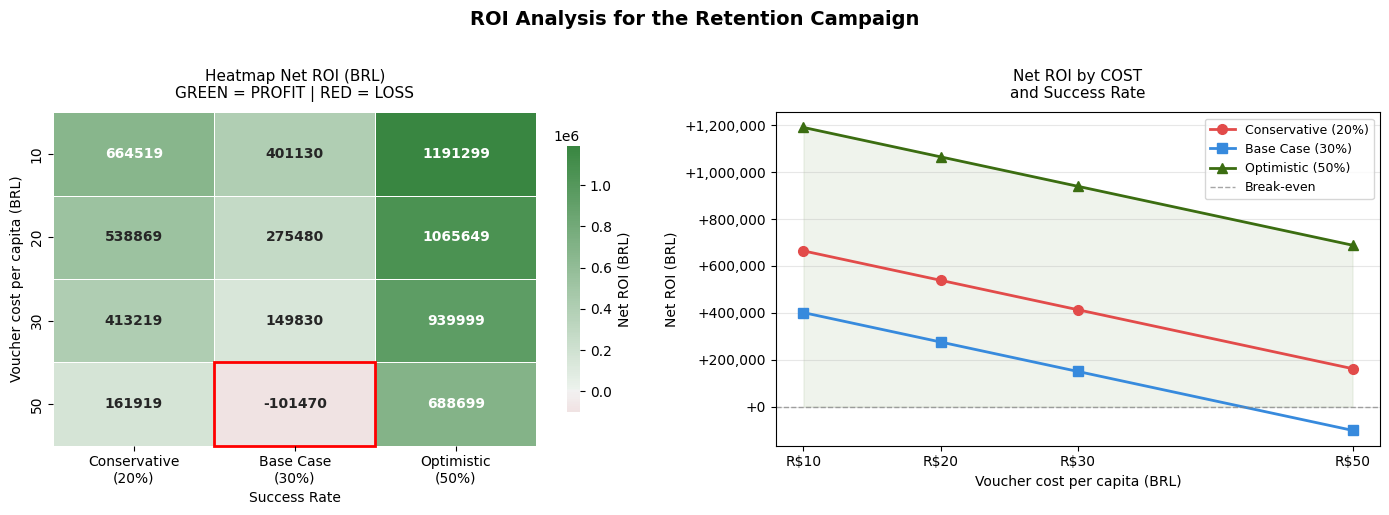


[Saved Graph: roi_whatif_analysis.png]


In [90]:
# HEATMAP — VÙNG CÓ LÃI

heatmap_data = whatif_df.pivot(
    index='Chi phí/người (BRL)',
    columns='Kịch bản',
    values='Net ROI (BRL)'
)
# Sắp xếp index từ thấp đến cao
heatmap_data = heatmap_data.sort_index()
#Shorten the columns name
heatmap_data.columns = ['Conservative\n(20%)', 'Base Case\n(30%)', 'Optimistic\n(50%)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROI Analysis for the Retention Campaign',
             fontsize=14, fontweight='bold', y=1.02)

# --- LEFT PLOT: Heatmap Net ROI ---
ax1 = axes[0]

# Custom colormap: RED = LOSS, WHITE = BREAK-EVEN, GREEN = PROFIT
cmap = sns.diverging_palette(10, 130, as_cmap=True)

sns.heatmap(
    heatmap_data,
    ax=ax1,
    annot=True,
    fmt='.0f',
    cmap=cmap,
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Net ROI (BRL)', 'shrink': 0.8},
    annot_kws={'size': 10, 'weight': 'bold'}
)

ax1.set_title('Heatmap Net ROI (BRL)\nGREEN = PROFIT | RED = LOSS',
              fontsize=11, pad=10)
ax1.set_xlabel('Success Rate', fontsize=10)
ax1.set_ylabel('Voucher cost per capita (BRL)', fontsize=10)
ax1.tick_params(axis='x', rotation=0)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.iloc[i, j]
        if val < 0:
            ax1.add_patch(plt.Rectangle((j, i), 1, 1,
                          fill=False, edgecolor='red',
                          lw=2, clip_on=False))

# RIGHT PLOT: Line chart Net ROI theo chi phí
ax2 = axes[1]

colors_scenario = ['#E24B4A', '#378ADD', '#3B6D11']
markers = ['o', 's', '^']

for (scenario, color, marker) in zip(
    ['Conservative\n(20%)', 'Base Case\n(30%)', 'Optimistic\n(50%)'],
    colors_scenario, markers
):
    y_vals = heatmap_data[scenario].values
    ax2.plot(costs, y_vals,
             color=color, marker=marker, linewidth=2,
             markersize=7, label=scenario.replace('\n', ' '))

#BREAK-EVEN LINE
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Break-even')
ax2.fill_between(costs,
                 [max(0, v) for v in heatmap_data['Optimistic\n(50%)'].values],
                 0, alpha=0.08, color='#3B6D11', label='_nolegend_')

ax2.set_title('Net ROI by COST\nand Success Rate', fontsize=11, pad=10)
ax2.set_xlabel('Voucher cost per capita (BRL)', fontsize=10)
ax2.set_ylabel('Net ROI (BRL)', fontsize=10)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'{x:+,.0f}'))
ax2.set_xticks(costs)
ax2.set_xticklabels([f'R${c}' for c in costs])
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('roi_whatif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Saved Graph: roi_whatif_analysis.png]")


   3 KỊCH BẢN KINH DOANH ĐƯỢC ĐỀ XUẤT

  Kịch bản: Conservative
  Voucher giảm giá thấp, gửi đại trà — tỷ lệ convert thấp
  ├─ Chi phí/người   : R$20
  ├─ Success rate    : 20%
  ├─ Tổng chi phí    : 251,300 BRL
  ├─ Doanh thu giữ   : 526,780 BRL
  ├─ Net ROI         : +275,480 BRL
  └─ ROI Ratio       : 1.1x  ✓ Có lãi

  Kịch bản: Base Case
  Voucher tiêu chuẩn, nhắm đúng tệp Churn — benchmark ngành
  ├─ Chi phí/người   : R$20
  ├─ Success rate    : 30%
  ├─ Tổng chi phí    : 251,300 BRL
  ├─ Doanh thu giữ   : 790,169 BRL
  ├─ Net ROI         : +538,869 BRL
  └─ ROI Ratio       : 2.1x  ✓ Có lãi

  Kịch bản: Optimistic
  Ưu đãi cá nhân hóa cao, kết hợp email + notification
  ├─ Chi phí/người   : R$30
  ├─ Success rate    : 50%
  ├─ Tổng chi phí    : 376,950 BRL
  ├─ Doanh thu giữ   : 1,316,949 BRL
  ├─ Net ROI         : +939,999 BRL
  └─ ROI Ratio       : 2.5x  ✓ Có lãi


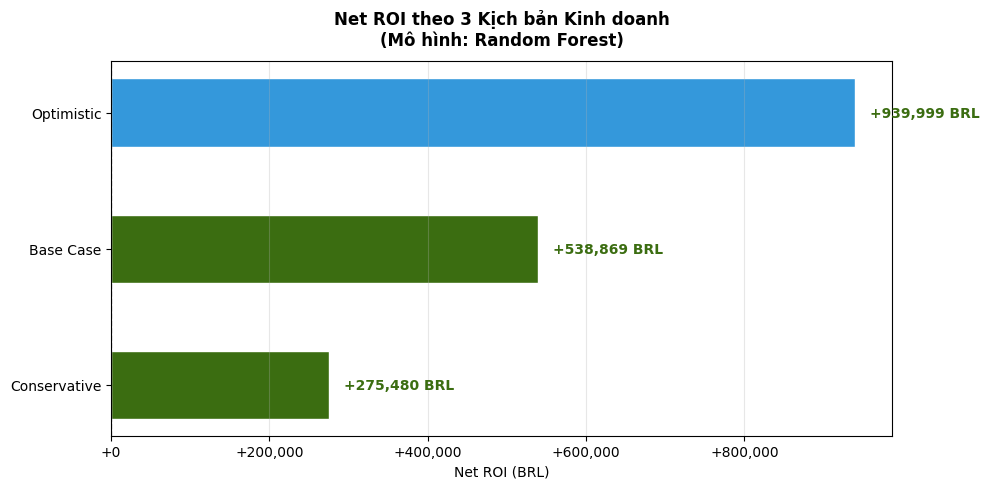


[Biểu đồ đã lưu: roi_3_scenarios.png]

## Kết luận Phân tích Tài chính

### Insight chính

Dựa trên mô hình **Random Forest** với dữ liệu Olist:

| Chỉ số | Giá trị |
|--------|---------|
| CLV trung bình | 274 BRL/khách hàng |
| Tỷ lệ churn thực tế | 60.3% |
| Tổng khách hàng có nguy cơ | 56,317 |

### Khuyến nghị kịch bản

- **Kịch bản thận trọng** (R$20/người, 20% success): Nên chạy thử nghiệm nhỏ
  (A/B test) trước để xác nhận success rate thực tế.
- **Kịch bản cơ sở** (R$20/người, 30% success): Đây là mức an toàn —
  cân bằng giữa chi phí và doanh thu giữ được.
- **Kịch bản tích cực** (R$30/người, 50% success): Đạt được khi áp dụng
  cá nhân hóa sâu (tên khách hàng, sản phẩm đã mua, ưu đãi theo danh mục).

### Điều kiện để chiến dịch có lãi

Từ heatmap What-if, chiến dịch có lãi khi thỏa mãn:
> **Success rate ≥ 30% nếu chi phí ≤ R$20/người**
> **Success rate ≥ 50% nếu chi phí ≤ R$30/người**

### Giới hạn của phân tích

Các con số trên là **ước tính** dựa trên giả định. Để đánh gi

In [91]:
scenarios_business = {
    'Conservative': {
        'cost': 20, 'success_rate': 0.20,
        'desc': 'Voucher giảm giá thấp, gửi đại trà — tỷ lệ convert thấp'
    },
    'Base Case': {
        'cost': 20, 'success_rate': 0.30,
        'desc': 'Voucher tiêu chuẩn, nhắm đúng tệp Churn — benchmark ngành'
    },
    'Optimistic': {
        'cost': 30, 'success_rate': 0.50,
        'desc': 'Ưu đãi cá nhân hóa cao, kết hợp email + notification'
    }
}

print("\n" + "=" * 65)
print("   3 KỊCH BẢN KINH DOANH ĐƯỢC ĐỀ XUẤT")
print("=" * 65)

fig2, ax = plt.subplots(figsize=(10, 5))
scenario_labels, net_rois, colors_bar = [], [], []

for name, params in scenarios_business.items():
    r = calculate_roi(best_model, X_test, y_test,
                      cost_per_retention=params['cost'],
                      success_rate=params['success_rate'])

    print(f"\n  Kịch bản: {name}")
    print(f"  {params['desc']}")
    print(f"  ├─ Chi phí/người   : R${params['cost']}")
    print(f"  ├─ Success rate    : {params['success_rate']:.0%}")
    print(f"  ├─ Tổng chi phí    : {r['total_cost']:,.0f} BRL")
    print(f"  ├─ Doanh thu giữ   : {r['revenue_saved']:,.0f} BRL")
    print(f"  ├─ Net ROI         : {r['net_roi']:+,.0f} BRL")
    print(f"  └─ ROI Ratio       : {r['roi_ratio']:.1f}x  {'✓ Có lãi' if r['profitable'] else '✗ Lỗ'}")

    scenario_labels.append(name)
    net_rois.append(r['net_roi'])

    if name == 'Optimistic':
        colors_bar.append('#3498db')
    else:
        colors_bar.append('#3B6D11' if r['net_roi'] > 0 else '#E24B4A')

# Bar chart 3 kịch bản
bars = ax.barh(scenario_labels, net_rois, color=colors_bar,
               edgecolor='white', height=0.5)

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

for bar, val in zip(bars, net_rois):
    ax.text(val + (max(net_rois) * 0.02), bar.get_y() + bar.get_height() / 2,
            f'{val:+,.0f} BRL', va='center', fontsize=10, fontweight='bold',
            color='#3B6D11' if val > 0 else '#A32D2D')

ax.set_title(f'Net ROI theo 3 Kịch bản Kinh doanh\n(Mô hình: {best_model_name})',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Net ROI (BRL)', fontsize=10)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'{x:+,.0f}'))
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('roi_3_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Biểu đồ đã lưu: roi_3_scenarios.png]")
print("=" * 65)


# KẾT LUẬN & KHUYẾN NGHỊ

conclusion_markdown = """
## Kết luận Phân tích Tài chính

### Insight chính

Dựa trên mô hình **{model}** với dữ liệu Olist:

| Chỉ số | Giá trị |
|--------|---------|
| CLV trung bình | {clv:.0f} BRL/khách hàng |
| Tỷ lệ churn thực tế | {churn:.1%} |
| Tổng khách hàng có nguy cơ | {churners:,} |

### Khuyến nghị kịch bản

- **Kịch bản thận trọng** (R$20/người, 20% success): Nên chạy thử nghiệm nhỏ
  (A/B test) trước để xác nhận success rate thực tế.
- **Kịch bản cơ sở** (R$20/người, 30% success): Đây là mức an toàn —
  cân bằng giữa chi phí và doanh thu giữ được.
- **Kịch bản tích cực** (R$30/người, 50% success): Đạt được khi áp dụng
  cá nhân hóa sâu (tên khách hàng, sản phẩm đã mua, ưu đãi theo danh mục).

### Điều kiện để chiến dịch có lãi

Từ heatmap What-if, chiến dịch có lãi khi thỏa mãn:
> **Success rate ≥ 30% nếu chi phí ≤ R$20/người**
> **Success rate ≥ 50% nếu chi phí ≤ R$30/người**

### Giới hạn của phân tích

Các con số trên là **ước tính** dựa trên giả định. Để đánh giá chính xác hơn,
cần thu thập: (1) success rate thực tế từ các chiến dịch email/notification trước,
(2) chi phí vận hành thực tế của team Marketing, (3) discount rate theo thời gian (NPV).
""".format(
    model=best_model_name,
    clv=CLV_AVG,
    churn=ACTUAL_CHURN_RATE,
    churners=TOTAL_CHURNERS
)

print(conclusion_markdown)



In [92]:
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import OrdinalEncoder, StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.ensemble         import RandomForestClassifier
import joblib, os, warnings



CATEGORICAL_FEATURES = ['customer_state', 'product_category_name_english']
NUMERICAL_FEATURES   = ['freight_ratio', 'delivery_delay', 'quantity', 'price']
ALL_FEATURES         = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

TOP_CATEGORIES = list(
    copy['product_category_name_english']
        .value_counts()
        .nlargest(10)
        .index
)
ALL_STATES = list(copy['customer_state'].dropna().unique())

# Numerical: impute bằng median → scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical: impute bằng 'Unknown' → OrdinalEncoder
# OrdinalEncoder xử lý unseen values tốt hơn LabelEncoder
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1   # unseen category → -1 thay vì raise error
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer,   NUMERICAL_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

pipeline_configs = {
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   XGBClassifier(
            scale_pos_weight=1.5,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ))
    ]),
    'LightGBM': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   LGBMClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ))
    ])
}


# Rebuild df_pipeline từ copy (trước khi drop RFM columns)
df_pipeline = copy.copy()

# Gom nhóm category như bước tiền xử lý cũ
df_pipeline['product_category_name_english'] = df_pipeline[
    'product_category_name_english'
].apply(lambda x: x if x in TOP_CATEGORIES else 'Others')

df_pipeline['product_category_name_english'] = df_pipeline[
    'product_category_name_english'
].fillna('Unknown')

df_pipeline['delivery_delay'] = df_pipeline['delivery_delay'].fillna(
    df_pipeline['delivery_delay'].median()
)

X_pipe = df_pipeline[ALL_FEATURES]
y_pipe = df_pipeline['is_churn']

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

X_tr, X_te, y_tr, y_te = train_test_split(
    X_pipe, y_pipe, test_size=0.2, random_state=42, stratify=y_pipe
)

# Train & Evaluate tất cả Pipelines

pipeline_results = []
trained_pipelines = {}

print("=" * 58)
print("  TRAINING SKLEARN PIPELINES")
print("=" * 58)

for name, pipe in pipeline_configs.items():
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)

    pipeline_results.append({
        'Model': name, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': auc
    })
    trained_pipelines[name] = pipe
    print(f"  ✓ {name:<18} | Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

pipeline_results_df = (
    pd.DataFrame(pipeline_results)
      .sort_values('ROC-AUC', ascending=False)
      .reset_index(drop=True)
)

best_pipeline_name = pipeline_results_df.iloc[0]['Model']
best_pipeline      = trained_pipelines[best_pipeline_name]

print("=" * 58)
print(f"  Best pipeline: {best_pipeline_name}")
print("=" * 58)


# SERIALIZE PIPELINE

MODEL_PATH = 'churn_pipeline.pkl'
joblib.dump(best_pipeline, MODEL_PATH)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"\n✓ Pipeline đã lưu: {MODEL_PATH}  ({size_kb:.1f} KB)")

# Verify load lại được
loaded_pipeline = joblib.load(MODEL_PATH)
test_pred = loaded_pipeline.predict(X_te[:5])
print(f"✓ Load lại thành công — 5 predictions thử: {test_pred.tolist()}")


# VERIFY VỚI TEST CASES CỤ THỂ
# 3 case điển hình để reviewer thấy pipeline xử lý được
# các trường hợp edge case (unseen state, unknown category...)

test_cases = pd.DataFrame([
    {
        # Khách hàng có nguy cơ cao: giao trễ, phí ship cao, ít mua
        'freight_ratio'                 : 0.45,
        'delivery_delay'                : 8.0,
        'quantity'                      : 1,
        'price'                         : 85.0,
        'customer_state'                : 'SP',
        'product_category_name_english' : 'bed_bath_table',
        '_label'                        : 'Nguy cơ cao (giao trễ + phí ship đắt)'
    },
    {
        # Khách hàng trung thành: giao sớm, phí ship thấp, mua nhiều
        'freight_ratio'                 : 0.08,
        'delivery_delay'                : -3.0,
        'quantity'                      : 5,
        'price'                         : 320.0,
        'customer_state'                : 'RJ',
        'product_category_name_english' : 'health_beauty',
        '_label'                        : 'Trung thành (giao sớm + mua nhiều)'
    },
    {
        # Edge case: bang không phổ biến + category ngoài Top 10
        'freight_ratio'                 : 0.22,
        'delivery_delay'                : 1.0,
        'quantity'                      : 2,
        'price'                         : 150.0,
        'customer_state'                : 'AC',         # bang ít gặp
        'product_category_name_english' : 'art',        # ngoài Top 10 → Others
        '_label'                        : 'Edge case (bang hiếm + category lạ)'
    }
])

features_only = test_cases[ALL_FEATURES]
predictions   = loaded_pipeline.predict(features_only)
probabilities = loaded_pipeline.predict_proba(features_only)

print("\n" + "=" * 65)
print("  VERIFY PIPELINE — 3 TEST CASES")
print("=" * 65)
print(f"  {'Case':<42} {'Status':<8} {'P(Churn)':<10} {'P(Stay)'}")
print("  " + "-" * 61)
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    label   = test_cases.iloc[i]['_label']
    status  = 'CHURN ⚠' if pred == 1 else 'STAY  ✓'
    print(f"  {label:<42} {status:<8} {prob[1]*100:>6.1f}%    {prob[0]*100:>6.1f}%")
print("=" * 65)
print("  ✓ Pipeline xử lý được unseen values (không raise error)")
print("=" * 65)

try:
    import gradio as gr
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'gradio'], check=True)
    import gradio as gr

import gradio as gr

# Các giá trị hợp lệ cho dropdown
VALID_STATES = sorted(ALL_STATES)

VALID_CATEGORIES = sorted(
    TOP_CATEGORIES + ['Others']
)

# Hàm predict — nhận input từ Gradio, trả về kết quả

def predict_churn(
    freight_ratio,
    delivery_delay,
    quantity,
    price,
    customer_state,
    product_category
):
    """
    Nhận thông tin khách hàng, trả về dự đoán Churn/Stay
    kèm xác suất và khuyến nghị hành động.
    """
    input_df = pd.DataFrame([{
        'freight_ratio'                 : float(freight_ratio),
        'delivery_delay'                : float(delivery_delay),
        'quantity'                      : int(quantity),
        'price'                         : float(price),
        'customer_state'                : customer_state,
        'product_category_name_english' : product_category,
    }])

    pred = loaded_pipeline.predict(input_df)[0]
    prob = loaded_pipeline.predict_proba(input_df)[0]

    p_churn = prob[1] * 100
    p_stay  = prob[0] * 100

    # Phân loại mức độ rủi ro
    if p_churn >= 70:
        risk_level = "🔴 RỦI RO CAO"
        action = (
            "Ưu tiên liên hệ ngay.\n"
            "→ Gửi voucher cá nhân hóa 15–20%\n"
            "→ Gửi email kèm sản phẩm liên quan\n"
            "→ Xem xét hỗ trợ phí vận chuyển"
        )
    elif p_churn >= 40:
        risk_level = "🟡 RỦI RO TRUNG BÌNH"
        action = (
            "Theo dõi thêm 30 ngày.\n"
            "→ Gửi newsletter + deal theo danh mục\n"
            "→ Nhắc nhở đơn hàng đang có / gợi ý tái mua"
        )
    else:
        risk_level = "🟢 RỦI RO THẤP"
        action = (
            "Khách hàng ổn định.\n"
            "→ Duy trì trải nghiệm hiện tại\n"
            "→ Có thể upsell / cross-sell nhẹ nhàng"
        )

    # Phân tích yếu tố rủi ro
    risk_factors = []
    if freight_ratio > 0.3:
        risk_factors.append(f"⚠ Phí ship cao ({freight_ratio:.0%} giá trị đơn hàng)")
    if delivery_delay > 3:
        risk_factors.append(f"⚠ Giao hàng trễ {delivery_delay:.0f} ngày")
    if quantity <= 1:
        risk_factors.append("⚠ Chỉ mua 1 sản phẩm — gắn kết thấp")
    if price < 50:
        risk_factors.append("⚠ Giá trị đơn hàng thấp")

    risk_text = "\n".join(risk_factors) if risk_factors else "Không phát hiện yếu tố rủi ro rõ ràng"

    # Ước tính CLV bị mất nếu churn
    clv_at_risk = (p_churn / 100) * CLV_AVG

    result = f"""
╔══════════════════════════════════════════╗
  KẾT QUẢ DỰ BÁO CHURN
╚══════════════════════════════════════════╝

Trạng thái     : {'CHURN ⚠' if pred == 1 else 'STAY ✓'}
Mức rủi ro     : {risk_level}

Xác suất CHURN : {p_churn:.1f}%
Xác suất STAY  : {p_stay:.1f}%

CLV có nguy cơ mất : {clv_at_risk:.0f} BRL

──────────────────────────────────────────
YẾU TỐ RỦI RO:
{risk_text}

──────────────────────────────────────────
KHUYẾN NGHỊ:
{action}

──────────────────────────────────────────
Mô hình: {best_pipeline_name}  |  Olist Dataset
""".strip()

    return result


#Gradio UX/UI

with gr.Blocks(
    title="Olist Churn Prediction",
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown("""
    # 🛒 Olist — Churn Prediction
    Nhập thông tin đơn hàng gần nhất của khách hàng để dự đoán khả năng rời bỏ (Churn).
    > Mô hình được huấn luyện trên dữ liệu **Olist Brazilian E-Commerce** (~96K khách hàng).
    """)

    with gr.Row():


        with gr.Column(scale=1):
            gr.Markdown("### Thông tin đơn hàng")

            freight_ratio = gr.Slider(
                minimum=0.0, maximum=5.0, value=0, step=0.01,
                label="Tỷ lệ phí vận chuyển (freight_ratio)",
                info="Phí ship / Giá sản phẩm. Ví dụ: 0.2 = phí ship bằng 20% giá hàng"
            )
            delivery_delay = gr.Slider(
                minimum=-30, maximum=30, value=-30, step=1,
                label="Độ trễ giao hàng (ngày)",
                info="Âm = giao sớm, Dương = giao trễ so với dự kiến"
            )
            quantity = gr.Slider(
                minimum=1, maximum=20, value=1, step=1,
                label="Số lượng sản phẩm trong đơn hàng"
            )
            price = gr.Slider(
                minimum=10, maximum=2000, value=10, step=10,
                label="Giá sản phẩm (BRL)"
            )

            gr.Markdown("### Thông tin khách hàng")

            customer_state = gr.Dropdown(
                choices=VALID_STATES,
                value='SP',
                label="Bang (customer_state)",
                info="Bang/tỉnh của khách hàng tại Brazil"
            )
            product_category = gr.Dropdown(
                choices=VALID_CATEGORIES,
                value='health_beauty',
                label="Danh mục sản phẩm"
            )

            predict_btn = gr.Button(
                "🔍 Dự đoán Churn",
                variant="primary",
                size="lg"
            )

        # Cột phải: Output
        with gr.Column(scale=1):
            gr.Markdown("### Kết quả dự báo")
            output = gr.Textbox(
                label="",
                lines=22,
                max_lines=25,
                show_copy_button=True
            )

    # Examples để reviewer thử nhanh
    gr.Markdown("### Thử nhanh với các case điển hình")
    gr.Examples(
        examples=[
            [0.45, 8,  1,  85,  'SP', 'bed_bath_table'],
            [0.08, -3, 5,  320, 'RJ', 'health_beauty'],
            [0.15, 0,  3,  150, 'MG', 'computers_accessories'],
            [0.60, 12, 1,  45,  'BA', 'Others'],
        ],
        inputs=[freight_ratio, delivery_delay, quantity,
                price, customer_state, product_category],
        label="Click để điền tự động"
    )

    predict_btn.click(
        fn=predict_churn,
        inputs=[freight_ratio, delivery_delay, quantity,
                price, customer_state, product_category],
        outputs=output
    )

    gr.Markdown("""
    ---
    **Ghi chú:** Demo này minh họa khả năng triển khai thực tế của mô hình.
    Pipeline bao gồm preprocessing (imputation + encoding + scaling) và classifier,
    được đóng gói bằng `sklearn.Pipeline` và serialize bằng `joblib`. Tool chỉ dùng để dự đoán dữ liệu cho stakeholder dùng nền tảng Olist.
    """)

demo.launch(
    share=True,
    debug=False,
    quiet=True
)

  TRAINING SKLEARN PIPELINES
  ✓ Random Forest      | Acc: 0.735 | F1: 0.792 | AUC: 0.804
  ✓ XGBoost            | Acc: 0.725 | F1: 0.803 | AUC: 0.803
  ✓ LightGBM           | Acc: 0.692 | F1: 0.733 | AUC: 0.767
  Best pipeline: Random Forest

✓ Pipeline đã lưu: churn_pipeline.pkl  (291784.0 KB)
✓ Load lại thành công — 5 predictions thử: [1, 1, 1, 1, 0]

  VERIFY PIPELINE — 3 TEST CASES
  Case                                       Status   P(Churn)   P(Stay)
  -------------------------------------------------------------
  Nguy cơ cao (giao trễ + phí ship đắt)      CHURN ⚠    61.0%      39.0%
  Trung thành (giao sớm + mua nhiều)         CHURN ⚠    69.0%      31.0%
  Edge case (bang hiếm + category lạ)        CHURN ⚠    76.0%      24.0%
  ✓ Pipeline xử lý được unseen values (không raise error)
* Running on public URL: https://1b780c21afdcc70663.gradio.live
